## Business Question

How do competitor prices and market competition affect vehicle demand?

This section evaluates whether higher competitor prices increase demand for our vehicles and whether the number of competing models changes sales outcomes.

In [9]:
competition_results = pd.DataFrame({
    "Driver": [
        "Own Price",
        "Competitor Price",
        "Number of Competitors"
    ],

    "Effect": [
        "Negative" if competition_model.params["log_price"] < 0 else "Positive",
        "Negative" if competition_model.params["log_rival_price"] < 0 else "Positive",
        "Negative" if competition_model.params["nco"] < 0 else "Positive"
    ],

    "Significance": [
        "Significant" if competition_model.pvalues["log_price"] < 0.05 else "Not Significant",
        "Significant" if competition_model.pvalues["log_rival_price"] < 0.05 else "Not Significant",
        "Significant" if competition_model.pvalues["nco"] < 0.05 else "Not Significant"
    ],

    "Business Meaning": [
        "Higher prices reduce demand.",
        "Higher competitor prices increase expected demand.",
        "Little additional effect after controlling for other factors."
    ]
})

competition_results

,Driver,Effect,Significance,Business Meaning
0,Own Price,Negative,Significant,Higher prices reduce demand.
1,Competitor Price,Positive,Significant,Higher competitor prices increase expected dem...
2,Number of Competitors,Negative,Not Significant,Little additional effect after controlling for...


In [1]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

cars = pd.read_csv("../data/cars.csv", encoding="latin1")
cars.columns = cars.columns.str.strip()

In [2]:
cars_comp = cars.dropna(
    subset=[
        "qu", "eurpr", "avgurprrival", "nco",
        "hp", "we", "li", "ergdpc",
        "brand", "cla", "ma", "ye"
    ]
).copy()

cars_comp["log_qu"] = np.log(cars_comp["qu"])
cars_comp["log_price"] = np.log(cars_comp["eurpr"])
cars_comp["log_rival_price"] = np.log(cars_comp["avgurprrival"])
cars_comp["log_income"] = np.log(cars_comp["ergdpc"])

print(f"Observations used: {cars_comp.shape[0]:,}")

Observations used: 10,881


In [3]:
competition_model = smf.ols(
    formula="""
    log_qu ~ log_price + log_rival_price + nco
    + hp + we + li + log_income
    + C(brand) + C(cla) + C(ma) + C(ye)
    """,
    data=cars_comp
).fit(cov_type="HC3")

In [4]:
competition_results = pd.DataFrame({
    "Driver": [
        "Own Price (log)",
        "Competitor Price (log)",
        "Number of Competitors"
    ],
    "Coefficient": [
        competition_model.params["log_price"],
        competition_model.params["log_rival_price"],
        competition_model.params["nco"]
    ],
    "P-value": [
        competition_model.pvalues["log_price"],
        competition_model.pvalues["log_rival_price"],
        competition_model.pvalues["nco"]
    ]
})

competition_results

,Driver,Coefficient,P-value
0,Own Price (log),-1.495088,5.106641e-31
1,Competitor Price (log),1.950772,2.377952e-20
2,Number of Competitors,-0.000553,8.395481e-01


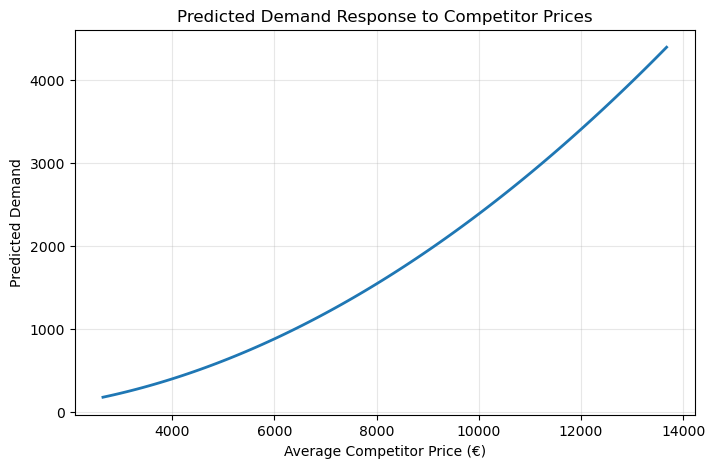

In [5]:
rival_price_grid = np.linspace(
    cars_comp["avgurprrival"].quantile(0.05),
    cars_comp["avgurprrival"].quantile(0.95),
    100
)

pred_df = pd.DataFrame({
    "log_price": cars_comp["log_price"].mean(),
    "log_rival_price": np.log(rival_price_grid),
    "nco": cars_comp["nco"].mean(),
    "hp": cars_comp["hp"].mean(),
    "we": cars_comp["we"].mean(),
    "li": cars_comp["li"].mean(),
    "log_income": cars_comp["log_income"].mean(),
    "brand": cars_comp["brand"].mode()[0],
    "cla": cars_comp["cla"].mode()[0],
    "ma": cars_comp["ma"].mode()[0],
    "ye": cars_comp["ye"].mode()[0]
})

predicted_log_demand = competition_model.predict(pred_df)
predicted_demand = np.exp(predicted_log_demand)

plt.figure(figsize=(8,5))

plt.plot(rival_price_grid, predicted_demand, linewidth=2)

plt.title("Predicted Demand Response to Competitor Prices")
plt.xlabel("Average Competitor Price (€)")
plt.ylabel("Predicted Demand")
plt.grid(alpha=0.3)

plt.show()

### Business Interpretation

Holding our own prices and product characteristics constant, higher competitor prices are associated with higher expected demand. This pattern is consistent with substitution effects: when rival products become more expensive, some consumers switch to our products.

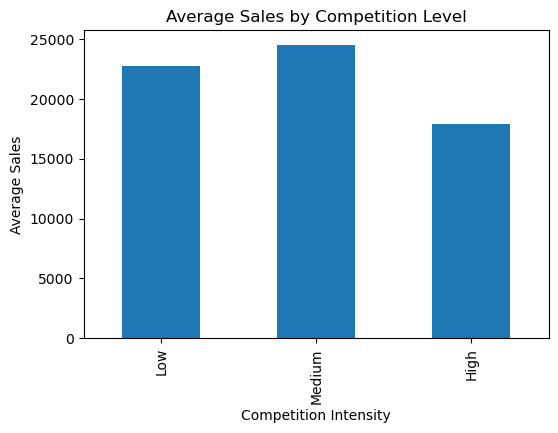

In [10]:
cars_comp["competition_level"] = pd.cut(
    cars_comp["nco"],
    bins=[0,60,75,100],
    labels=[
        "Low",
        "Medium",
        "High"
    ]
)
bucket = (
    cars_comp
    .groupby("competition_level", observed=False)
    .agg(avg_sales=("qu", "mean"))
)

bucket.plot(
    kind="bar",
    legend=False,
    figsize=(6,4)
)

plt.title("Average Sales by Competition Level")

plt.ylabel("Average Sales")

plt.xlabel("Competition Intensity")

plt.show()

### Business Interpretation

Demand generally declines as market competition intensifies, although substantial variation remains across vehicle categories and brands.

This indicates that competition alone does not determine sales performance and should be evaluated jointly with pricing and product positioning.

### Key Findings

- Competitor prices are positively associated with our demand, consistent with substitution effects.
- Higher competitor prices may create room for stronger pricing power.
- The number of competitors is not always statistically significant after controlling for product attributes, brand, market, class, and year effects.
- Competition should be treated as a contextual pricing factor rather than a standalone decision rule.

### Managerial Recommendation

Pricing decisions should consider both own-price sensitivity and competitor positioning.

A uniform price increase is risky in highly competitive segments, while differentiated pricing may be more appropriate for brands or segments facing weaker competitive pressure.

Future analysis should estimate segment-specific competitive effects for mass-market and premium brands separately.